In [2]:
%matplotlib widget

In [3]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd
import os
from astropy.modeling import models
import astropy.units as u

In [4]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/NGC3049/FORS2.2022-01-16T07_25_38.100/NGC-3049_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data
image_error = hdul[1].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/NGC3049/FORS2.2022-01-16T07_25_38.100/NGC-3049_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     387   (2094, 965)   float32   
  1  IMAGE.ERR     1 ImageHDU        68   (2094, 965)   float32   


In [5]:
image_cut = image[67:167, 0:1890]
image_error_cut = image_error[67:167, 0:1890]

Text(0.5, 0, 'wavelenght')

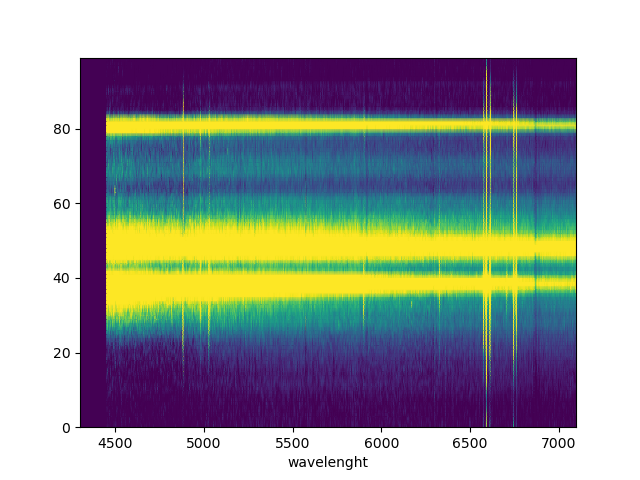

In [6]:
wv = np.arange(4300.74, 4300.74+1890*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wv, y)
plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelenght')

In [7]:
z = 0.00485
l_HA = 6563 * (1+z)
l_HB = 4861 * (1+z) 
l_NII_1 = 6548 * (1+z) 
l_NII_2 = 6583 * (1+z)
l_SII_1 = 6717 * (1+z)
l_SII_2 = 6731 * (1+z)
l_OIII_1 = 4959 * (1+z)
l_OIII_2 = 5007 * (1+z)
seeing = 1.984
sigma = seeing/2.35

In [18]:
4340.5*(1+z)

4361.551425

Text(0, 0.5, 'Flux [$10^{-16} erg/(cm^2 s \\AA )$]')

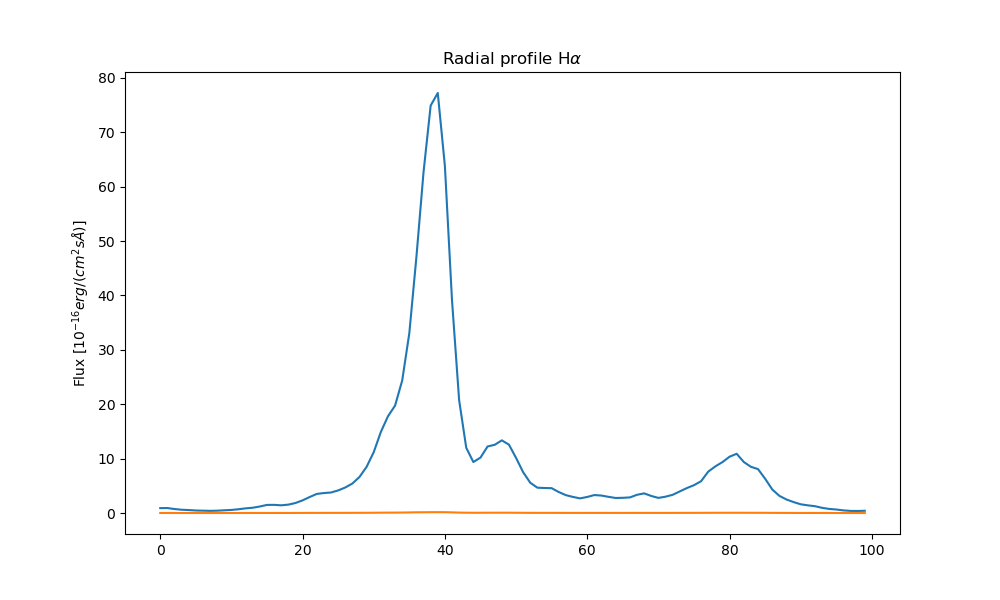

In [7]:
mask_HA = (wv > l_HA-8)*(wv < l_HA+8)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
radial_profile_HA = np.sum(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_HA)
plt.plot(x_axes, radial_profile_error_HA)
plt.title(r'Radial profile H$\alpha$')
plt.ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')

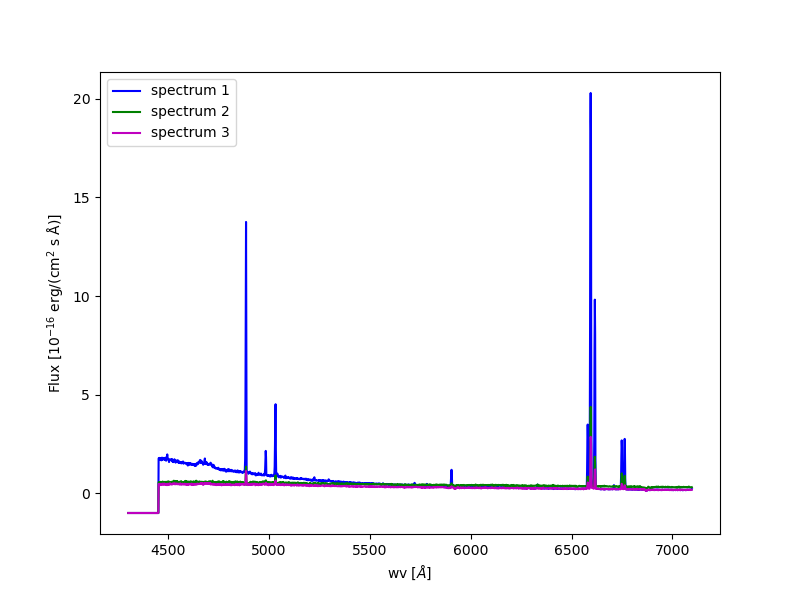

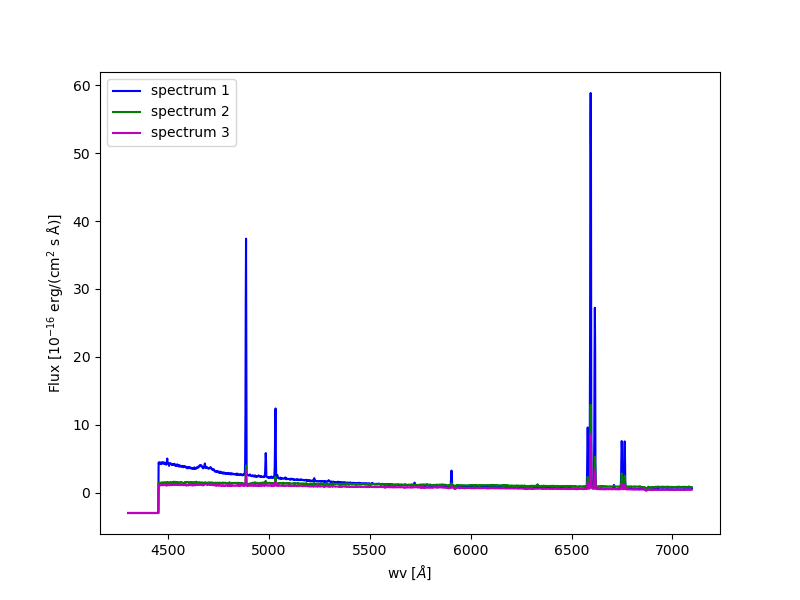

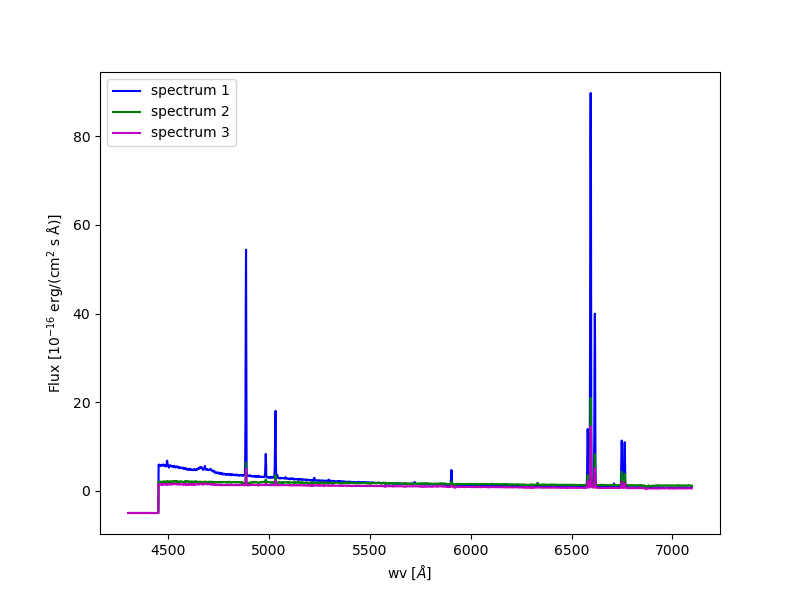

In [8]:
#fit_HA = pd.read_csv("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_789/Fit/Halpha_fit.csv", index_col=0)
os.makedirs('1Sigma', exist_ok=True)
os.makedirs('2Sigma', exist_ok=True)
os.makedirs('3Sigma', exist_ok=True)

peaks = [39, 48, 81] #, 58.8]       #fit_HA.iloc[3].values

plt.figure(figsize=(8,6))
spectra_1 =  np.zeros((len(peaks), image_cut.shape[1]))
spectra_err_1 = np.zeros((len(peaks), image_error_cut.shape[1]))
data1 = []
colors = ['blue', 'green', 'm']#, 'orange']
#Cut one sigma 
for i in range(len(peaks)):
    mask = (x_axes > peaks[i]-sigma)*(x_axes < peaks[i]+sigma)
    spectra_1[i] = np.sum(image_cut[mask, :], axis = 0)
    spectra_err_1[i] = np.sqrt(np.sum(image_error_cut[mask, :]**2, axis = 0)) #The error is the squared sum of the errors of each pixels (y) 
    plt.plot(wv, spectra_1[i], color = colors[i], label = f'spectrum {i+1}')
    plt.legend()
    plt.xlabel(r'wv [$\AA$]')
    plt.ylabel(r'Flux [$10^{-16}$ erg/(cm$^2$ s Å)]')
    
    spectrum_table = np.concatenate((wv.reshape(-1, 1), 
                                    spectra_1[i].reshape(-1, 1), spectra_err_1[i].reshape(-1, 1)), axis=1)
    filename = os.path.join('1Sigma', f'Spectrum_1s_{i+1}.txt')  
    np.savetxt(filename, spectrum_table)

plt.figure(figsize=(8,6))
spectra_2 =  np.zeros((len(peaks), image_cut.shape[1]))
spectra_err_2 = np.zeros((len(peaks), image_error_cut.shape[1]))
data2 = []

#Cut two sigma 
for i in range(len(peaks)):
    mask = (x_axes > peaks[i]-2*sigma)*(x_axes < peaks[i]+2*sigma)
    spectra_2[i] = np.sum(image_cut[mask, :], axis = 0)
    spectra_err_2[i] = np.sqrt(np.sum(image_error_cut[mask, :]**2, axis = 0)) #The error is the squared sum of the errors of each pixels (y) 
    plt.plot(wv, spectra_2[i], color = colors[i], label = f'spectrum {i+1}')
    plt.legend()
    plt.xlabel(r'wv [$\AA$]')
    plt.ylabel(r'Flux [$10^{-16}$ erg/(cm$^2$ s Å)]')
    
    spectrum_table = np.concatenate((wv.reshape(-1, 1), 
                                    spectra_2[i].reshape(-1, 1), spectra_err_2[i].reshape(-1, 1)), axis=1)
    filename = os.path.join('2Sigma', f'Spectrum_2s_{i+1}.txt')  
    np.savetxt(filename, spectrum_table)
    
plt.figure(figsize=(8,6))
spectra_3 =  np.zeros((len(peaks), image_cut.shape[1]))
spectra_err_3 = np.zeros((len(peaks), image_error_cut.shape[1]))
data3 = []
#Cut three sigma 
for i in range(len(peaks)):
    mask = (x_axes > peaks[i]-3*sigma)*(x_axes < peaks[i]+3*sigma)
    spectra_3[i] = np.sum(image_cut[mask, :], axis = 0)
    spectra_err_3[i] = np.sqrt(np.sum(image_error_cut[mask, :]**2, axis = 0)) #The error is the squared sum of the errors of each pixels (y) 
    plt.plot(wv, spectra_3[i], color = colors[i], label = f'spectrum {i+1}')
    plt.legend()
    plt.xlabel(r'wv [$\AA$]')
    plt.ylabel(r'Flux [$10^{-16}$ erg/(cm$^2$ s Å)]')
    
    spectrum_table = np.concatenate((wv.reshape(-1, 1), 
                                    spectra_3[i].reshape(-1, 1), spectra_err_3[i].reshape(-1, 1)), axis=1)
    filename = os.path.join('3Sigma', f'Spectrum_3s_{i+1}.txt') 
    np.savetxt(filename, spectrum_table)

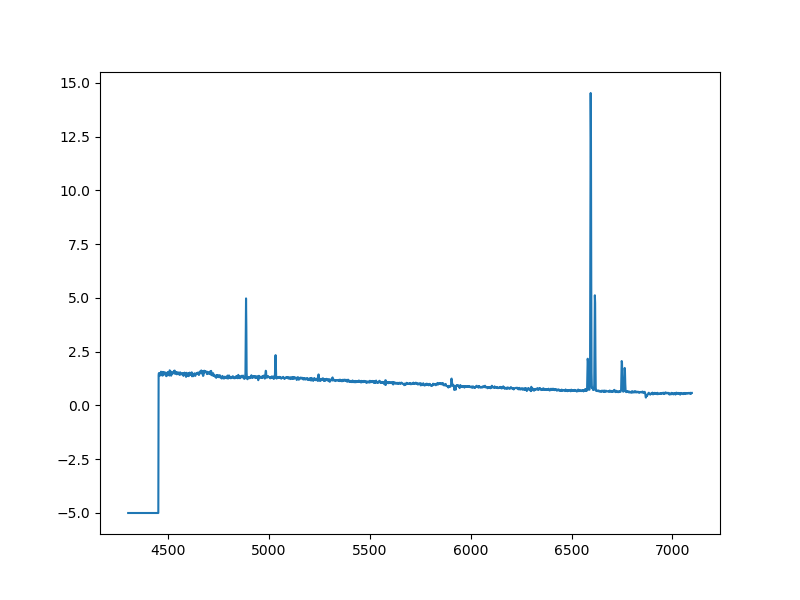

In [9]:
plt.figure(figsize=(8,6))
plt.plot(wv, spectra_3[2])

## S/N continuum
Fare segnale/rumore per ogni pixel e poi fai la media, questo per le tre regioni

In [19]:
import pandas as pd

mask_continuum_1 = (wv > 4550)*(wv < 4850)
mask_continuum_2 = (wv > 5300)*(wv < 5800)
mask_continuum_3 = (wv > 5920)*(wv < 6250)

# Liste per contenere i risultati
SNR = []
Signal = []
Noise = []

# Calcolo per ogni spettro
for i in range(len(peaks)):  # Assumendo che peaks definisca il numero di spettri
    snr = []
    signal = []
    noise = []
    
    # Calcolo per continuum_1
    sig_1 = np.mean(spectra_1[i, mask_continuum_1])
    noise_1 = np.std(spectra_1[i, mask_continuum_1])
    snr_1 = sig_1 / noise_1
    
    # Calcolo per continuum_2  
    sig_2 = np.mean(spectra_1[i, mask_continuum_2])
    noise_2 = np.std(spectra_1[i, mask_continuum_2])
    snr_2 = sig_2 / noise_2
    
    # Calcolo per continuum_3
    sig_3 = np.mean(spectra_1[i, mask_continuum_3])
    noise_3 = np.std(spectra_1[i, mask_continuum_3])
    snr_3 = sig_3 / noise_3
    
    # Aggiunta ai risultati
    snr.extend([snr_1, snr_2, snr_3])
    signal.extend([sig_1, sig_2, sig_3])
    noise.extend([noise_1, noise_2, noise_3])
    
    SNR.append(snr)
    Signal.append(signal)
    Noise.append(noise)

# Conversione in array numpy e trasposizione
SNR_array = np.array(SNR).T  # Trasponi per avere continuum come righe
Signal_array = np.array(Signal).T
Noise_array = np.array(Noise).T

# Creazione del DataFrame
# Nomi delle colonne per ogni spettro
col_names = [f'Spectrum_{i+1}' for i in range(len(peaks))]

# Creazione di DataFrames separati per ogni metrica
df_snr = pd.DataFrame(SNR_array, 
                      columns=col_names,
                      index=['Continuum_1', 'Continuum_2', 'Continuum_3'])

df_signal = pd.DataFrame(Signal_array, 
                         columns=col_names,
                         index=['Continuum_1', 'Continuum_2', 'Continuum_3'])

df_noise = pd.DataFrame(Noise_array, 
                        columns=col_names,
                        index=['Continuum_1', 'Continuum_2', 'Continuum_3'])

# Combinazione in un unico DataFrame con MultiIndex per le colonne
df_combined = pd.concat([df_snr, df_signal, df_noise], 
                        keys=['SNR', 'Signal', 'Noise'], 
                        axis=1)

print("DataFrame SNR:")
print(df_snr)
print("\nDataFrame Signal:")
print(df_signal)
print("\nDataFrame Noise:")
print(df_noise)
print("\nDataFrame Combinato:")
print(df_combined)

# Salvataggio dei file
df_path_snr = os.path.join('1Sigma', 'SNR_1s_continuum.csv')
df_path_signal = os.path.join('1Sigma', 'Signal_1s_continuum.csv')
df_path_noise = os.path.join('1Sigma', 'Noise_1s_continuum.csv')
df_path_combined = os.path.join('1Sigma', 'Combined_1s_continuum.csv')

# Assicurati che la directory esista
os.makedirs('1Sigma', exist_ok=True)

df_snr.to_csv(df_path_snr, float_format='%.3f')
df_signal.to_csv(df_path_signal, float_format='%.3f')
df_noise.to_csv(df_path_noise, float_format='%.3f')
df_combined.to_csv(df_path_combined, float_format='%.3f')

print(f"\nFile salvati in:")
print(f"- {df_path_snr}")
print(f"- {df_path_signal}")
print(f"- {df_path_noise}")
print(f"- {df_path_combined}")

DataFrame SNR:
             Spectrum_1  Spectrum_2  Spectrum_3
Continuum_1    7.770720   24.321854   17.570042
Continuum_2    7.291755   17.613994   13.690465
Continuum_3   13.584515   23.013082   20.170374

DataFrame Signal:
             Spectrum_1  Spectrum_2  Spectrum_3
Continuum_1    1.372154    0.567354    0.455878
Continuum_2    0.479781    0.452390    0.330748
Continuum_3    0.310215    0.401195    0.269070

DataFrame Noise:
             Spectrum_1  Spectrum_2  Spectrum_3
Continuum_1    0.176580    0.023327    0.025946
Continuum_2    0.065798    0.025684    0.024159
Continuum_3    0.022836    0.017433    0.013340

DataFrame Combinato:
                   SNR                           Signal                        \
            Spectrum_1 Spectrum_2 Spectrum_3 Spectrum_1 Spectrum_2 Spectrum_3   
Continuum_1   7.770720  24.321854  17.570042   1.372154   0.567354   0.455878   
Continuum_2   7.291755  17.613994  13.690465   0.479781   0.452390   0.330748   
Continuum_3  13.584515  23

In [20]:
# Liste per contenere i risultati
SNR = []
Signal = []
Noise = []

# Calcolo per ogni spettro
for i in range(len(peaks)):  # Assumendo che peaks definisca il numero di spettri
    snr = []
    signal = []
    noise = []
    
    # Calcolo per continuum_1
    sig_1 = np.mean(spectra_2[i, mask_continuum_1])
    noise_1 = np.std(spectra_2[i, mask_continuum_1])
    snr_1 = sig_1 / noise_1
    
    # Calcolo per continuum_2  
    sig_2 = np.mean(spectra_2[i, mask_continuum_2])
    noise_2 = np.std(spectra_2[i, mask_continuum_2])
    snr_2 = sig_2 / noise_2
    
    # Calcolo per continuum_3
    sig_3 = np.mean(spectra_2[i, mask_continuum_3])
    noise_3 = np.std(spectra_2[i, mask_continuum_3])
    snr_3 = sig_3 / noise_3
    
    # Aggiunta ai risultati
    snr.extend([snr_1, snr_2, snr_3])
    signal.extend([sig_1, sig_2, sig_3])
    noise.extend([noise_1, noise_2, noise_3])
    
    SNR.append(snr)
    Signal.append(signal)
    Noise.append(noise)

# Conversione in array numpy e trasposizione
SNR_array = np.array(SNR).T  # Trasponi per avere continuum come righe
Signal_array = np.array(Signal).T
Noise_array = np.array(Noise).T

# Creazione del DataFrame
# Nomi delle colonne per ogni spettro
col_names = [f'Spectrum_{i+1}' for i in range(len(peaks))]

# Creazione di DataFrames separati per ogni metrica
df_snr = pd.DataFrame(SNR_array, 
                      columns=col_names,
                      index=['Continuum_1', 'Continuum_2', 'Continuum_3'])

df_signal = pd.DataFrame(Signal_array, 
                         columns=col_names,
                         index=['Continuum_1', 'Continuum_2', 'Continuum_3'])

df_noise = pd.DataFrame(Noise_array, 
                        columns=col_names,
                        index=['Continuum_1', 'Continuum_2', 'Continuum_3'])

# Combinazione in un unico DataFrame con MultiIndex per le colonne
df_combined = pd.concat([df_snr, df_signal, df_noise], 
                        keys=['SNR', 'Signal', 'Noise'], 
                        axis=1)

print("DataFrame SNR:")
print(df_snr)
print("\nDataFrame Signal:")
print(df_signal)
print("\nDataFrame Noise:")
print(df_noise)
print("\nDataFrame Combinato:")
print(df_combined)

# Salvataggio dei file
df_path_snr = os.path.join('2Sigma', 'SNR_2s_continuum.csv')
df_path_signal = os.path.join('2Sigma', 'Signal_2s_continuum.csv')
df_path_noise = os.path.join('2Sigma', 'Noise_2s_continuum.csv')
df_path_combined = os.path.join('2Sigma', 'Combined_2s_continuum.csv')

# Assicurati che la directory esista
os.makedirs('2Sigma', exist_ok=True)

df_snr.to_csv(df_path_snr, float_format='%.3f')
df_signal.to_csv(df_path_signal, float_format='%.3f')
df_noise.to_csv(df_path_noise, float_format='%.3f')
df_combined.to_csv(df_path_combined, float_format='%.3f')

print(f"\nFile salvati in:")
print(f"- {df_path_snr}")
print(f"- {df_path_signal}")
print(f"- {df_path_noise}")
print(f"- {df_path_combined}")

DataFrame SNR:
             Spectrum_1  Spectrum_2  Spectrum_3
Continuum_1    7.475336   28.096170   16.013694
Continuum_2    7.631330   21.352146   15.304283
Continuum_3   13.977323   26.531148   20.999168

DataFrame Signal:
             Spectrum_1  Spectrum_2  Spectrum_3
Continuum_1    3.368803    1.444581    1.112486
Continuum_2    1.273621    1.207819    0.828204
Continuum_3    0.821420    1.059689    0.658291

DataFrame Noise:
             Spectrum_1  Spectrum_2  Spectrum_3
Continuum_1    0.450656    0.051416    0.069471
Continuum_2    0.166894    0.056567    0.054116
Continuum_3    0.058768    0.039941    0.031348

DataFrame Combinato:
                   SNR                           Signal                        \
            Spectrum_1 Spectrum_2 Spectrum_3 Spectrum_1 Spectrum_2 Spectrum_3   
Continuum_1   7.475336  28.096170  16.013694   3.368803   1.444581   1.112486   
Continuum_2   7.631330  21.352146  15.304283   1.273621   1.207819   0.828204   
Continuum_3  13.977323  26

In [21]:
# Liste per contenere i risultati
SNR = []
Signal = []
Noise = []

# Calcolo per ogni spettro
for i in range(len(peaks)):  # Assumendo che peaks definisca il numero di spettri
    snr = []
    signal = []
    noise = []
    
    # Calcolo per continuum_1
    sig_1 = np.mean(spectra_3[i, mask_continuum_1])
    noise_1 = np.std(spectra_3[i, mask_continuum_1])
    snr_1 = sig_1 / noise_1
    
    # Calcolo per continuum_2  
    sig_2 = np.mean(spectra_3[i, mask_continuum_2])
    noise_2 = np.std(spectra_3[i, mask_continuum_2])
    snr_2 = sig_2 / noise_2
    
    # Calcolo per continuum_3
    sig_3 = np.mean(spectra_3[i, mask_continuum_3])
    noise_3 = np.std(spectra_3[i, mask_continuum_3])
    snr_3 = sig_3 / noise_3
    
    # Aggiunta ai risultati
    snr.extend([snr_1, snr_2, snr_3])
    signal.extend([sig_1, sig_2, sig_3])
    noise.extend([noise_1, noise_2, noise_3])
    
    SNR.append(snr)
    Signal.append(signal)
    Noise.append(noise)

# Conversione in array numpy e trasposizione
SNR_array = np.array(SNR).T  # Trasponi per avere continuum come righe
Signal_array = np.array(Signal).T
Noise_array = np.array(Noise).T

# Creazione del DataFrame
# Nomi delle colonne per ogni spettro
col_names = [f'Spectrum_{i+1}' for i in range(len(peaks))]

# Creazione di DataFrames separati per ogni metrica
df_snr = pd.DataFrame(SNR_array, 
                      columns=col_names,
                      index=['Continuum_1', 'Continuum_2', 'Continuum_3'])

df_signal = pd.DataFrame(Signal_array, 
                         columns=col_names,
                         index=['Continuum_1', 'Continuum_2', 'Continuum_3'])

df_noise = pd.DataFrame(Noise_array, 
                        columns=col_names,
                        index=['Continuum_1', 'Continuum_2', 'Continuum_3'])

# Combinazione in un unico DataFrame con MultiIndex per le colonne
df_combined = pd.concat([df_snr, df_signal, df_noise], 
                        keys=['SNR', 'Signal', 'Noise'], 
                        axis=1)

print("DataFrame SNR:")
print(df_snr)
print("\nDataFrame Signal:")
print(df_signal)
print("\nDataFrame Noise:")
print(df_noise)
print("\nDataFrame Combinato:")
print(df_combined)

# Salvataggio dei file
df_path_snr = os.path.join('3Sigma', 'SNR_3s_continuum.csv')
df_path_signal = os.path.join('3Sigma', 'Signal_3s_continuum.csv')
df_path_noise = os.path.join('3Sigma', 'Noise_3s_continuum.csv')
df_path_combined = os.path.join('3Sigma', 'Combined_3s_continuum.csv')

# Assicurati che la directory esista
os.makedirs('3Sigma', exist_ok=True)

df_snr.to_csv(df_path_snr, float_format='%.3f')
df_signal.to_csv(df_path_signal, float_format='%.3f')
df_noise.to_csv(df_path_noise, float_format='%.3f')
df_combined.to_csv(df_path_combined, float_format='%.3f')

print(f"\nFile salvati in:")
print(f"- {df_path_snr}")
print(f"- {df_path_signal}")
print(f"- {df_path_noise}")
print(f"- {df_path_combined}")

DataFrame SNR:
             Spectrum_1  Spectrum_2  Spectrum_3
Continuum_1    7.398655   27.440389   14.684121
Continuum_2    8.084544   22.570381   15.322953
Continuum_3   14.469516   26.069492   20.030388

DataFrame Signal:
             Spectrum_1  Spectrum_2  Spectrum_3
Continuum_1    4.453425    1.992377    1.415071
Continuum_2    1.791346    1.714471    1.075588
Continuum_3    1.179852    1.494246    0.842546

DataFrame Noise:
             Spectrum_1  Spectrum_2  Spectrum_3
Continuum_1    0.601924    0.072607    0.096367
Continuum_2    0.221577    0.075961    0.070195
Continuum_3    0.081541    0.057318    0.042063

DataFrame Combinato:
                   SNR                           Signal                        \
            Spectrum_1 Spectrum_2 Spectrum_3 Spectrum_1 Spectrum_2 Spectrum_3   
Continuum_1   7.398655  27.440389  14.684121   4.453425   1.992377   1.415071   
Continuum_2   8.084544  22.570381  15.322953   1.791346   1.714471   1.075588   
Continuum_3  14.469516  26

## S/N emission lines 

In [22]:
def SNR_line(wv, wv_line, spectra, peaks):
    left_region = (wv > wv_line-25)*(wv < wv_line-10) 
    right_region = (wv > wv_line+10)*(wv < wv_line+25) 
    clean_mask = left_region | right_region

    mask = (wv > wv_line-8)*(wv < wv_line+8)
    wv_bin = np.array(np.where(mask == True))
    Signal = []
    Noise = []
    SNR = []
    for i in range(len(peaks)):
        flux = spectra[i, mask] - np.mean(spectra[i, clean_mask])
        signal = (np.trapz(flux, wv[mask]))
        noise = np.std(spectra[i, clean_mask] - np.mean(spectra[i, clean_mask]))*1.48*np.sqrt(wv_bin.shape[1]) #std*delta(wv)*number of A under the line
        SNR.append(signal/noise)
        Signal.append(signal)
        Noise.append(noise)
   # print(SNR)
   # print(Signal)
   # print(Noise)
    return SNR, Signal, Noise 

def SNR_SII_line(wv, wv_line, spectra, peaks):
    left_region = (wv > 6740-15)*(wv < 6740) 
    right_region = (wv > 6769)*(wv < 6769+15) 
    clean_mask = left_region | right_region

    mask = (wv > wv_line-8)*(wv < wv_line+8)
    wv_bin = np.array(np.where(mask == True))
    Signal = []
    Noise = []
    SNR = []
    for i in range(len(peaks)):
        flux = spectra[i, mask] - np.mean(spectra[i, clean_mask])
        signal = (np.trapz(flux, wv[mask]))
        noise = np.std(spectra[i, clean_mask] - np.mean(spectra[i, clean_mask]))*1.48*np.sqrt(wv_bin.shape[1]) #std*delta(wv)*number of A under the line
        SNR.append(signal/noise)
        Signal.append(signal)
        Noise.append(noise)
   # print(SNR)
   # print(Signal)
   # print(Noise)
    return SNR, Signal, Noise 

def SNR_HA_NII(wv, wv_line, spectra, peaks):
    left_region = (wv > 6570-15) & (wv < 6570)
    right_region = (wv > 6624) & (wv < 6624+15)
    clean_mask = left_region | right_region #But also for the two NII lines bc they are closed

    mask = (wv > wv_line-8)*(wv < wv_line+8)
    wv_bin = np.array(np.where(mask == True))

    Signal = []
    Noise = []
    SNR = []
    for i in range(len(peaks)):
        flux = spectra[i, mask] - np.mean(spectra[i, clean_mask])
        signal = (np.trapz(flux, wv[mask]))
        noise = np.std(spectra[i, clean_mask] - np.mean(spectra[i, clean_mask]))*1.48*np.sqrt(wv_bin.shape[1]) #std*delta(wv)*number of A under the line
        SNR.append(signal/noise)
        Signal.append(signal)
        Noise.append(noise)
    return SNR, Signal, Noise 

In [23]:
index = ['Component_1', 'Component_2', 'Component_3']#, 'Component_4']
SNR_HB_1, signal_HB_1, noise_HB_1 = SNR_line(wv, l_HB, spectra_1, peaks)
data = np.concatenate([
    np.array(SNR_HB_1).reshape(-1, 1),
    np.array(signal_HB_1).reshape(-1, 1),
    np.array(noise_HB_1).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index )
df_path = os.path.join('1Sigma', 'SNR_HB_1s.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_HB_2, signal_HB_2, noise_HB_2 = SNR_line(wv, l_HB, spectra_2, peaks)
data = np.concatenate([
    np.array(SNR_HB_2).reshape(-1, 1),
    np.array(signal_HB_2).reshape(-1, 1),
    np.array(noise_HB_2).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('2Sigma', 'SNR_HB_2s.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_HB_3, signal_HB_3, noise_HB_3 = SNR_line(wv, l_HB, spectra_3, peaks)
data = np.concatenate([
    np.array(SNR_HB_3).reshape(-1, 1),
    np.array(signal_HB_3).reshape(-1, 1),
    np.array(noise_HB_3).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('3Sigma', 'SNR_HB_3s.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_SII_1, signal_SII_1, noise_SII_1 = SNR_SII_line(wv, l_SII_1, spectra_1, peaks)
data = np.concatenate([
    np.array(SNR_SII_1).reshape(-1, 1),
    np.array(signal_SII_1).reshape(-1, 1),
    np.array(noise_SII_1).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('1Sigma','SNR_SII_1_1s.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_SII_2, signal_SII_2, noise_SII_2 = SNR_SII_line(wv, l_SII_1, spectra_2, peaks)
data = np.concatenate([
    np.array(SNR_SII_2).reshape(-1, 1),
    np.array(signal_SII_2).reshape(-1, 1),
    np.array(noise_SII_2).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('2Sigma','SNR_SII_1_2s.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_SII_3, signal_SII_3, noise_SII_3 = SNR_SII_line(wv, l_SII_1, spectra_3, peaks)
data = np.concatenate([
    np.array(SNR_SII_3).reshape(-1, 1),
    np.array(signal_SII_3).reshape(-1, 1),
    np.array(noise_SII_3).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('3Sigma','SNR_SII_1_3s.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_SII_2_1, signal_SII_2_1, noise_SII_2_1 = SNR_SII_line(wv, l_SII_2, spectra_1, peaks)
data = np.concatenate([
    np.array(SNR_SII_2_1).reshape(-1, 1),
    np.array(signal_SII_2_1).reshape(-1, 1),
    np.array(noise_SII_2_1).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('1Sigma','SNR_SII_2_1s.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_SII_2_2, signal_SII_2_2, noise_SII_2_2 = SNR_SII_line(wv, l_SII_2, spectra_2, peaks)
data = np.concatenate([
    np.array(SNR_SII_2_2).reshape(-1, 1),
    np.array(signal_SII_2_2).reshape(-1, 1),
    np.array(noise_SII_2_2).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('2Sigma','SNR_SII_2_2s.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_SII_2_3, signal_SII_2_3, noise_SII_2_3 = SNR_SII_line(wv, l_SII_2, spectra_3, peaks)
data = np.concatenate([
    np.array(SNR_SII_2_3).reshape(-1, 1),
    np.array(signal_SII_2_3).reshape(-1, 1),
    np.array(noise_SII_2_3).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('3Sigma','SNR_SII_2_3s.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_OIII_1, signal_OIII_1, noise_OIII_1 = SNR_line(wv, l_OIII_1, spectra_1, peaks)
data = np.concatenate([
    np.array(SNR_OIII_1).reshape(-1, 1),
    np.array(signal_OIII_1).reshape(-1, 1),
    np.array(noise_OIII_1).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('1Sigma', 'SNR_OIII_1_1s.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_OIII_2, signal_OIII_2, noise_OIII_2 = SNR_line(wv, l_OIII_1, spectra_2, peaks)
data = np.concatenate([
    np.array(SNR_OIII_2).reshape(-1, 1),
    np.array(signal_OIII_2).reshape(-1, 1),
    np.array(noise_OIII_2).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('2Sigma', 'SNR_OIII_1_2s.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_OIII_3, signal_OIII_3, noise_OIII_3 = SNR_line(wv, l_OIII_1, spectra_3, peaks)
data = np.concatenate([
    np.array(SNR_OIII_3).reshape(-1, 1),
    np.array(signal_OIII_3).reshape(-1, 1),
    np.array(noise_OIII_3).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('3Sigma', 'SNR_OIII_1_3s.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_OIII_2_1, signal_OIII_2_1, noise_OIII_2_1 = SNR_line(wv, l_OIII_2, spectra_1, peaks)
data = np.concatenate([
    np.array(SNR_OIII_2_1).reshape(-1, 1),
    np.array(signal_OIII_2_1).reshape(-1, 1),
    np.array(noise_OIII_2_1).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('1Sigma', 'SNR_OIII_2_1s.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_OIII_2_2, signal_OIII_2_2, noise_OIII_2_2 = SNR_line(wv, l_OIII_2, spectra_2, peaks)
data = np.concatenate([
    np.array(SNR_OIII_2_2).reshape(-1, 1),
    np.array(signal_OIII_2_2).reshape(-1, 1),
    np.array(noise_OIII_2_2).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('2Sigma', 'SNR_OIII_2_2s.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_OIII_2_3, signal_OIII_2_3, noise_OIII_2_3 = SNR_line(wv, l_OIII_2, spectra_3, peaks)
data = np.concatenate([
    np.array(SNR_OIII_2_3).reshape(-1, 1),
    np.array(signal_OIII_2_3).reshape(-1, 1),
    np.array(noise_OIII_2_3).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('3Sigma', 'SNR_OIII_2_3s.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_HA_1, signal_HA_1, noise_HA_1 = SNR_HA_NII(wv, l_HA, spectra_1, peaks)
data = np.concatenate([
    np.array(SNR_HA_1).reshape(-1, 1),
    np.array(signal_HA_1).reshape(-1, 1),
    np.array(noise_HA_1).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('1Sigma', 'SNR_HA_1s.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_HA_2, signal_HA_2, noise_HA_2 = SNR_HA_NII(wv, l_HA, spectra_2, peaks)
data = np.concatenate([
    np.array(SNR_HA_2).reshape(-1, 1),
    np.array(signal_HA_2).reshape(-1, 1),
    np.array(noise_HA_2).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('2Sigma', 'SNR_HA_2s.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_HA_3, signal_HA_3, noise_HA_3 = SNR_HA_NII(wv, l_HA, spectra_3, peaks)
data = np.concatenate([
    np.array(SNR_HA_3).reshape(-1, 1),
    np.array(signal_HA_3).reshape(-1, 1),
    np.array(noise_HA_3).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('3Sigma', 'SNR_HA_3s.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_NII_1, signal_NII_1, noise_NII_1 = SNR_HA_NII(wv, l_NII_1, spectra_1, peaks)
data = np.concatenate([
    np.array(SNR_NII_1).reshape(-1, 1),
    np.array(signal_NII_1).reshape(-1, 1),
    np.array(noise_NII_1).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('1Sigma', 'SNR_NII_1_1s.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_NII_2, signal_NII_2, noise_NII_2 = SNR_HA_NII(wv, l_NII_1, spectra_2, peaks)
data = np.concatenate([
    np.array(SNR_NII_2).reshape(-1, 1),
    np.array(signal_NII_2).reshape(-1, 1),
    np.array(noise_NII_2).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('2Sigma', 'SNR_NII_1_2s.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_NII_3, signal_NII_3, noise_NII_3 = SNR_HA_NII(wv, l_NII_1, spectra_3, peaks)
data = np.concatenate([
    np.array(SNR_NII_3).reshape(-1, 1),
    np.array(signal_NII_3).reshape(-1, 1),
    np.array(noise_NII_3).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('3Sigma', 'SNR_NII_1_3s.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_NII_2_1, signal_NII_2_1, noise_NII_2_1 = SNR_HA_NII(wv, l_NII_2, spectra_1, peaks)
data = np.concatenate([
    np.array(SNR_NII_2_1).reshape(-1, 1),
    np.array(signal_NII_2_1).reshape(-1, 1),
    np.array(noise_NII_2_1).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('1Sigma', 'SNR_NII_2_1s.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_NII_2_2, signal_NII_2_2, noise_NII_2_2 = SNR_HA_NII(wv, l_NII_2, spectra_2, peaks)
data = np.concatenate([
    np.array(SNR_NII_2_2).reshape(-1, 1),
    np.array(signal_NII_2_2).reshape(-1, 1),
    np.array(noise_NII_2_2).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('2Sigma', 'SNR_NII_2_2s.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_NII_2_3, signal_NII_2_3, noise_NII_2_3 = SNR_HA_NII(wv, l_NII_2, spectra_3, peaks)
data = np.concatenate([
    np.array(SNR_NII_2_3).reshape(-1, 1),
    np.array(signal_NII_2_3).reshape(-1, 1),
    np.array(noise_NII_2_3).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('3Sigma', 'SNR_NII_2_3s.csv')
df.to_csv(df_path, float_format='%.3f')

## Redshift

In [24]:
from astropy.modeling import models
import astropy.units as u
from specutils import Spectrum
import astropy.units as u
from specutils.fitting import find_lines_threshold, fit_generic_continuum
from specutils.manipulation import noise_region_uncertainty
from astropy.nddata import StdDevUncertainty
from astropy.modeling.fitting import LinearLSQFitter

Numero di righe trovate (regione centrale, wv > 4451 Å): 11
   line_center     line_type  line_center_index
     Angstrom                                  
------------------ ---------- -----------------
 4885.339999999827   emission               276
4983.0199999997985   emission               342
 5031.859999999784   emission               375
 5905.059999999527   emission               965
6579.9399999993275   emission              1421
 6594.739999999323   emission              1431
 6615.459999999317   emission              1445
 6748.659999999278   emission              1535
 6763.459999999273   emission              1545
 6868.539999999242 absorption              1616
6871.4999999992415 absorption              1618
Numero di righe trovate (regione centrale, wv > 4451 Å): 8
   line_center     line_type  line_center_index
     Angstrom                                  
------------------ ---------- -----------------
 4885.339999999827   emission               276
 5031.85999999978

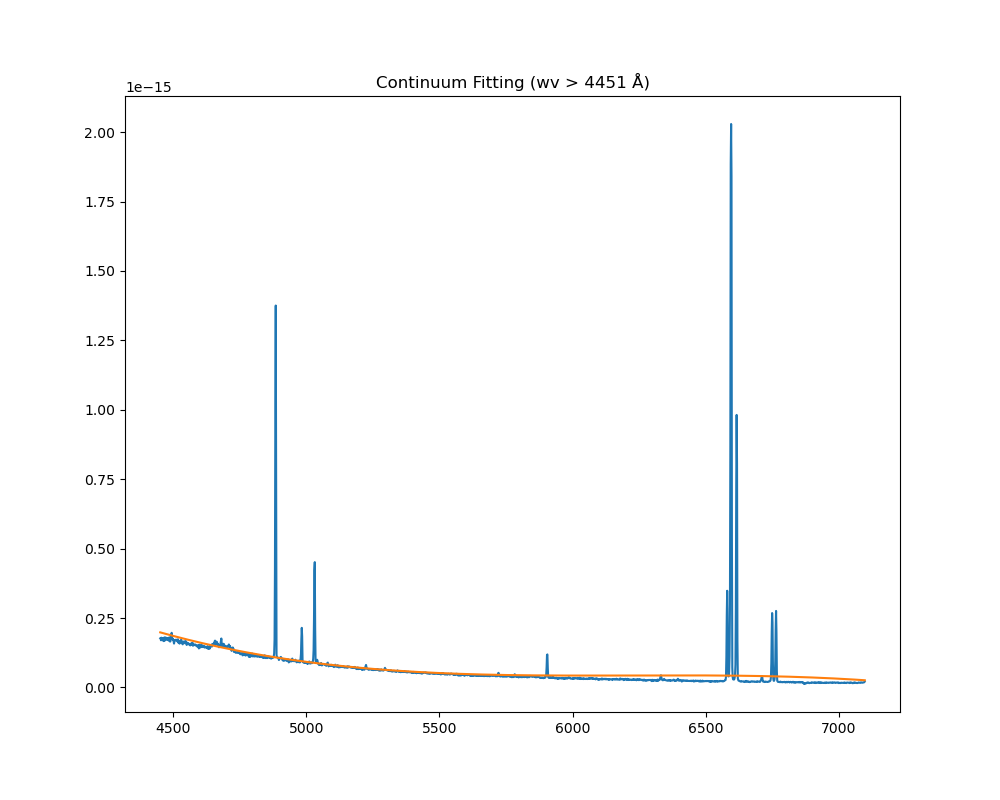

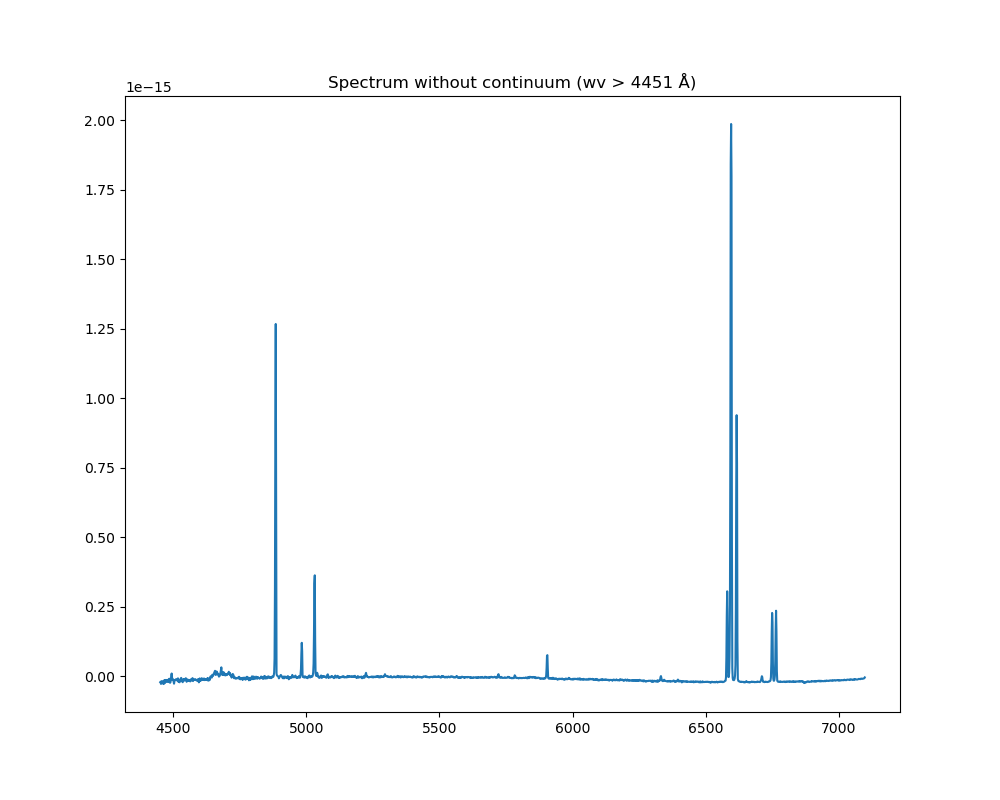

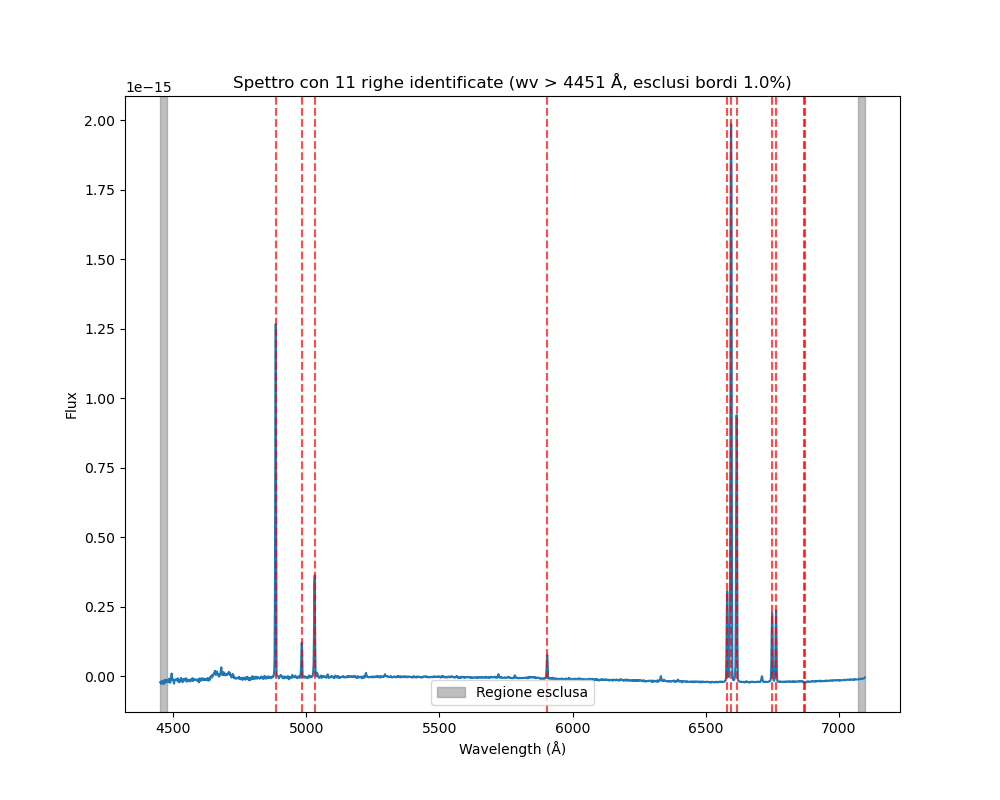

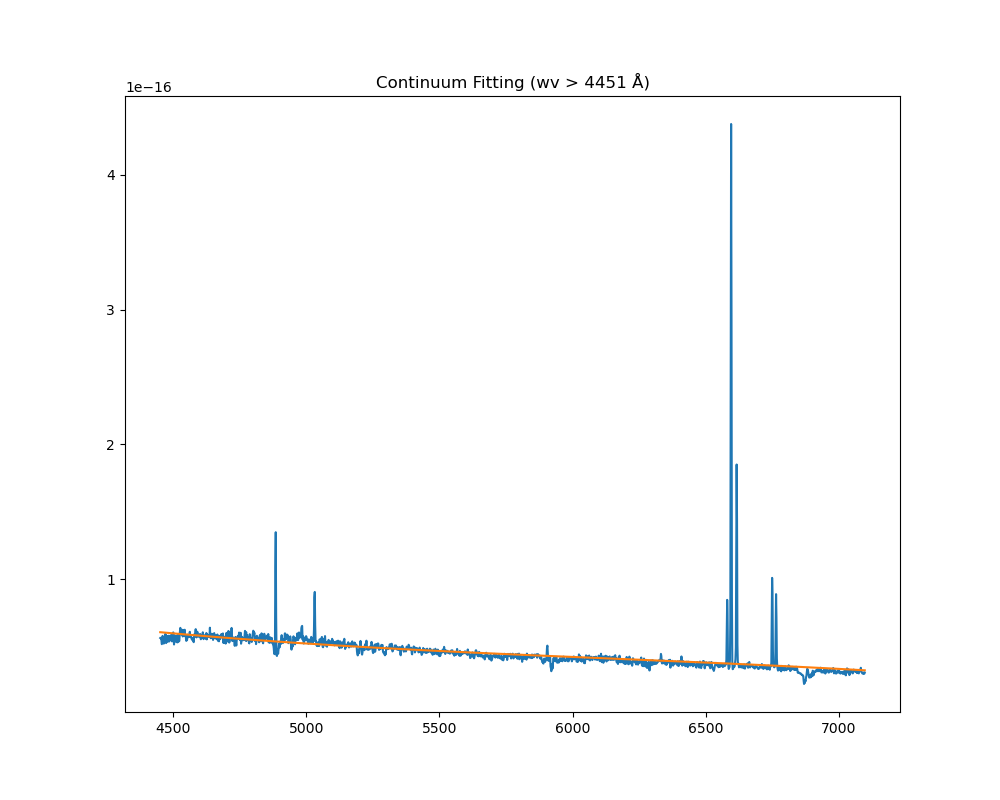

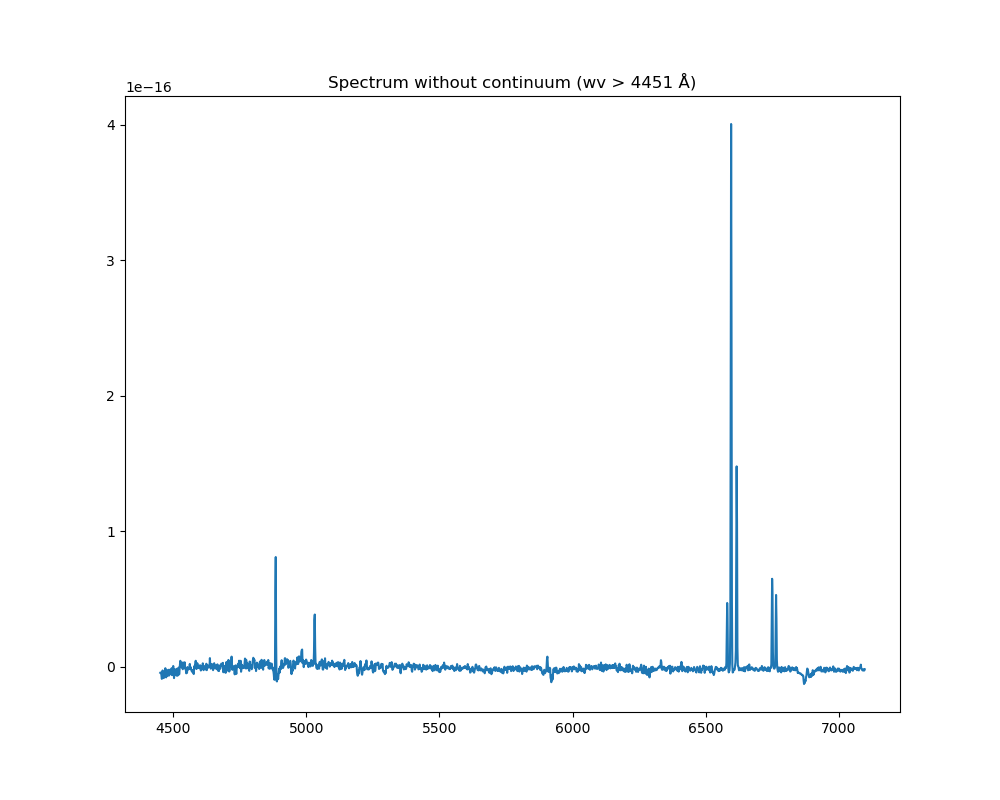

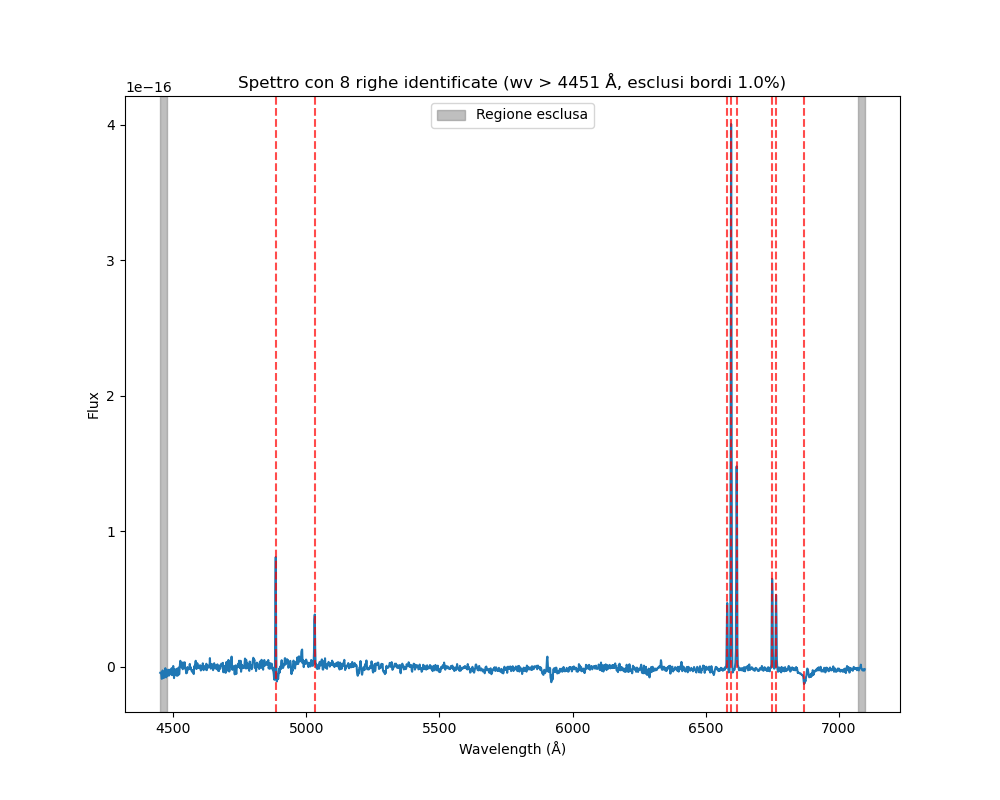

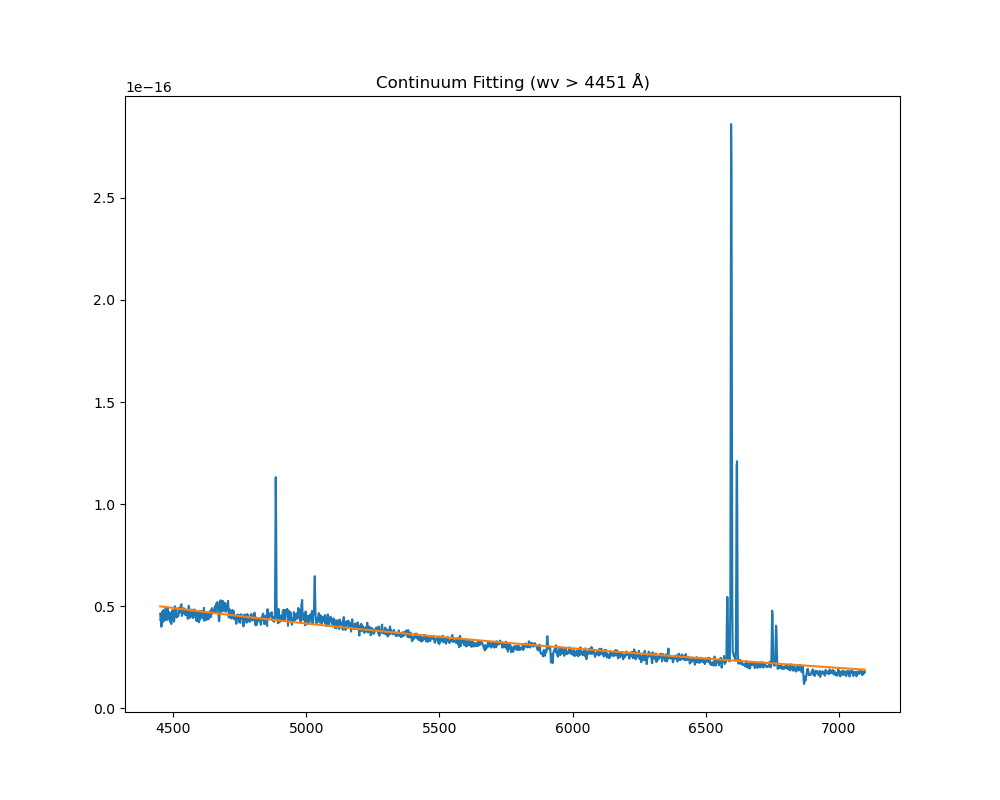

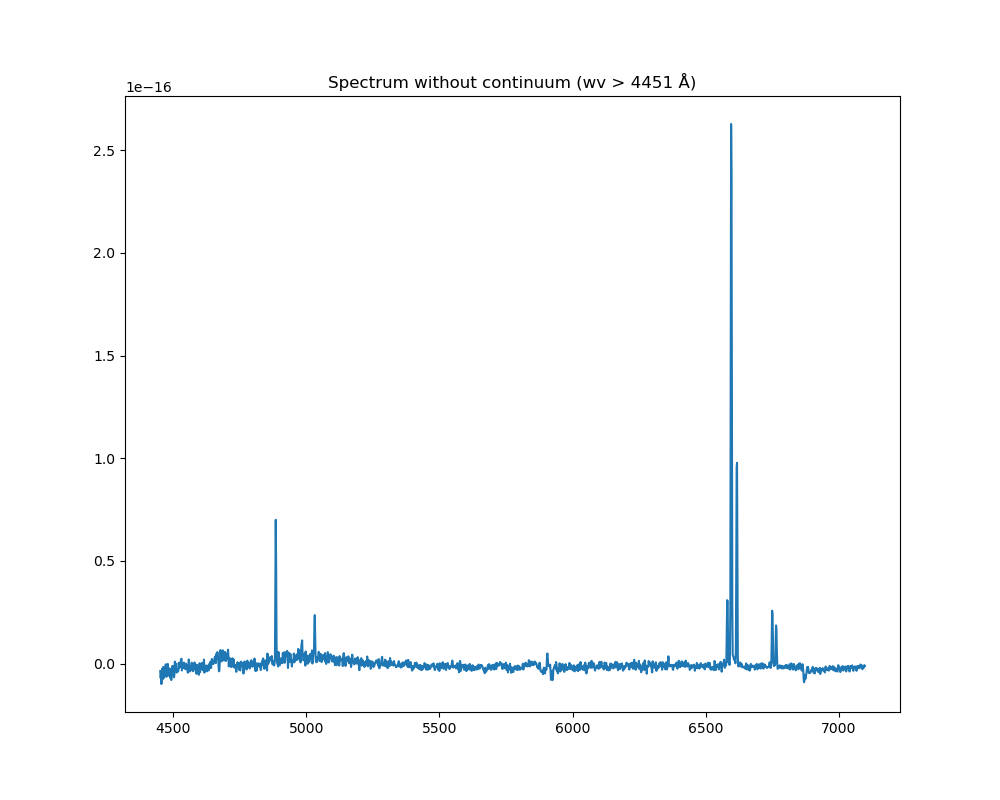

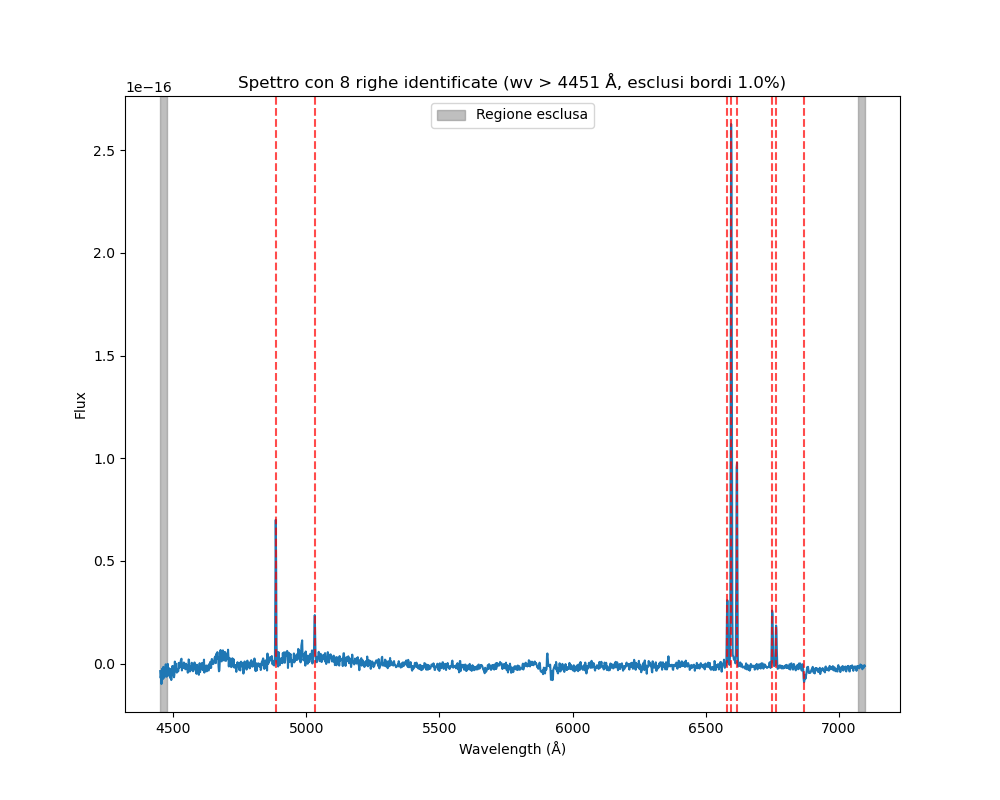

In [25]:
all_lines = []
noise_factor = [25, 10, 8 ]#, 18]

# Filtra per lunghezze d'onda > 4451 Å
wv_mask = wv > 4451
wv_filtered = wv[wv_mask]

# Definisci la percentuale di spettro da escludere ai bordi (es. 5% per lato)
edge_fraction = 0.01
n_points = len(wv_filtered)
start_idx = int(n_points * edge_fraction)
end_idx = int(n_points * (1 - edge_fraction))

# Crea gli array ritagliati per la regione centrale (già filtrata per wv > 4451)
wv_central = wv_filtered[start_idx:end_idx]

for i in range(len(peaks)):
    # Applica il filtro anche agli spettri
    spectra_filtered = spectra_1[i][wv_mask]
    spectra_err_filtered = spectra_err_1[i][wv_mask]
    
    # Usa lo spettro filtrato per il fitting del continuum
    spectrum = Spectrum(
        spectral_axis=wv_filtered * u.Angstrom,
        flux = spectra_filtered * 1e-16 *u.erg / (u.cm**2 * u.s * u.Angstrom),  
        uncertainty = StdDevUncertainty(spectra_err_filtered * 1e-16 *u.erg / (u.cm**2 * u.s * u.Angstrom))
    )
    
    g1_fit = fit_generic_continuum(spectrum, fitter=LinearLSQFitter())
    y_continuum_fitted = g1_fit(wv_filtered * u.Angstrom)
    
    f, ax = plt.subplots(figsize = (10,8))
    ax.plot(wv_filtered * u.Angstrom, spectra_filtered * 1e-16*u.erg / (u.cm**2 * u.s * u.Angstrom))
    ax.plot(wv_filtered * u.Angstrom, y_continuum_fitted)
    ax.set_title("Continuum Fitting (wv > 4451 Å)")
    
    flux_continuum_subtracted = spectrum.flux - y_continuum_fitted
    f2, ax2 = plt.subplots(figsize = (10,8))
    ax2.plot(wv_filtered * u.Angstrom, flux_continuum_subtracted)
    ax2.set_title("Spectrum without continuum (wv > 4451 Å)")
    
    # Crea lo spettro solo per la regione centrale (senza bordi, già filtrata per wv > 4451)
    spectrum_no_continuum_central = Spectrum(
        spectral_axis=wv_central * u.Angstrom,
        flux=flux_continuum_subtracted[start_idx:end_idx],
        uncertainty=StdDevUncertainty(spectra_err_filtered[start_idx:end_idx] * 1e-16 * u.erg / (u.cm**2 * u.s * u.Angstrom))
    )
    
    # Trova le righe solo nella regione centrale
    lines = find_lines_threshold(spectrum_no_continuum_central, noise_factor = noise_factor[i])
    print(f"Numero di righe trovate (regione centrale, wv > 4451 Å): {len(lines)}")
    print(lines)
    
    f3, ax3 = plt.subplots(figsize=(10,8))
    ax3.plot(wv_filtered, flux_continuum_subtracted.value)
    
    if len(lines) < 50:  # Solo se non sono troppe
        for line_pos in lines['line_center']:
            ax3.axvline(x=line_pos.value, color='r', alpha=0.7, linestyle='--')
    
    # Aggiungi linee verticali per indicare i bordi esclusi
    ax3.axvspan(wv_filtered[0], wv_filtered[start_idx], alpha=0.5, color='gray', zorder=1, label='Regione esclusa')
    ax3.axvspan(wv_filtered[end_idx-1], wv_filtered[-1], alpha=0.5, color='gray', zorder=1)
    ax3.legend()
    
    ax3.set_title(f"Spettro con {len(lines)} righe identificate (wv > 4451 Å, esclusi bordi {edge_fraction*100:.1f}%)")
    ax3.set_xlabel('Wavelength (Å)')
    ax3.set_ylabel('Flux')
    all_lines.append(lines)

In [27]:
#reference wv in air
l_Hgam = 4340.5
l_HA = 6562.8
l_HB = 4861.3
l_NII_1 = 6548.1
l_NII_2 = 6583.4
l_SII_1 = 6717.0
l_SII_2 = 6731.3
l_OIII_1 = 4958.9
l_OIII_2 = 5006.8
l_He_1 = 5875.6

lines_1 = [l_HB, l_OIII_1, l_OIII_2, l_He_1, l_NII_1, l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_2 = [l_HB, l_OIII_2, l_NII_1, l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_spectrum_1 = all_lines[0]['line_center'] 
lines_spectrum_2 = all_lines[1]['line_center']
lines_spectrum_3 = all_lines[2]['line_center']

z_1 = np.zeros(8)
z_2 = np.zeros(8)
z_3 = np.zeros(7)
#z_4 = np.zeros(8)

for i in range(8):
    z_1[i] = lines_spectrum_1[i].value / lines_1[i] - 1
   
#    z_4[i] = lines_spectrum_4[i].value / lines_1[i] - 1


for i in range(6):
    z_2[i] = lines_spectrum_2[i].value / lines_2[i] - 1
    z_3[i] = lines_spectrum_3[i].value / lines_2[i] - 1
z_1_mean = np.mean(z_1)
z_2_mean = np.mean(z_2)
z_3_mean = np.mean(z_3)
z_1_std = np.std(z_1)
z_2_std = np.std(z_2)
z_3_std = np.std(z_3) 

print(z_1_mean)
print(z_1_std)
print(z_2_mean)
print(z_2_std)
print(z_3_mean)
print(z_3_std)
#print(z_4_mean)
#print(z_4_std)
z = [z_1_mean, z_2_mean, z_3_mean] #, z_4_mean]
z_err = [z_1_std, z_2_std, z_3_std] #, z_4_std]

0.004892606540059324
9.026772392429537e-05
0.0036578642959508023
0.002113295154124978
0.00421253174537904
0.001723369744357001


C:\Users\ISAFA\AppData\Local\Temp\ipykernel_16260\3367636629.py:1: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(8, 6))


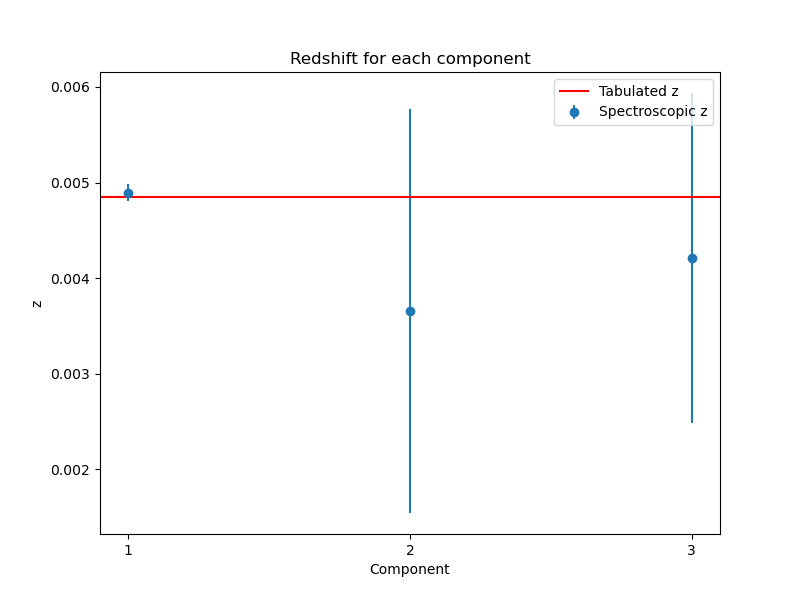

In [28]:
plt.figure(figsize=(8, 6))
comp = [1, 2, 3]
plt.errorbar(comp, z, z_err, ls='none', marker = 'o', label = 'Spectroscopic z')
plt.xlabel('Component')
plt.ylabel('z')
plt.xticks(comp)
plt.axhline(0.00485, color = 'red', label = 'Tabulated z')
plt.title('Redshift for each component')
plt.legend()
plt.savefig('Redshift', bbox_inches='tight')

red_table = np.column_stack((z, z_err))
np.savetxt('redshift.txt', red_table, header='redshift redshift_error', fmt='%.5f',delimiter='\t')